# Tree-Based Methods

## Agenda

1. Classification trees - decision trees for categorical targets
2. Ensemble methods
    1. Bagging
    2. Random forests
3. Tasks


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import numpy as np
import urllib
from sklearn import tree

# Suppress all warnings
warnings.filterwarnings('ignore')

import numpy as np
np.random.seed(42)


## Plot Functions

In [2]:
def plot_tree(model, features):
    plt.figure(figsize=(15, 10))
    tree.plot_tree(
        model,
        feature_names=features,
        proportion=True,
        precision=2,
        filled=True,
    )
    plt.show()


In [3]:
def plot_tree_scatter(model, df, target, feat1, feat2, scatterplot=True):
    fig, ax = plt.subplots(figsize=(10, 6))

    if scatterplot:
        sns.scatterplot(x=feat1, y=feat2, hue=target, data=df)

    x_min = df[feat1].min()
    x_max = df[feat1].max()
    y_min = df[feat2].min()
    y_max = df[feat2].max()
    node_bounds = {0: (x_min, x_max, y_min, y_max)}

    for node in range(model.tree_.node_count):
        curr_x_min, curr_x_max, curr_y_min, curr_y_max = node_bounds[node]

        if model.tree_.feature[node] == -2:
            center_x = (curr_x_min + curr_x_max) / 2
            center_y = (curr_y_min + curr_y_max) / 2

            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=UserWarning)
                # Check if model is regressor or classifier
                if hasattr(model, "predict_proba"):
                    # For classifier
                    prob_positive = model.predict_proba([[center_x, center_y]])[0][1]
                    color = plt.cm.coolwarm(prob_positive)
                else:
                    # For regressor
                    prediction = model.predict([[center_x, center_y]])[0]
                    # Normalize prediction to [0,1] for coloring
                    pred_min = df[target].min()
                    pred_max = df[target].max()
                    normalized_pred = (prediction - pred_min) / (pred_max - pred_min)
                    color = plt.cm.coolwarm(normalized_pred)

            plt.gca().add_patch(
                plt.Rectangle(
                    (curr_x_min, curr_y_min),
                    curr_x_max - curr_x_min,
                    curr_y_max - curr_y_min,
                    color=color,
                    alpha=0.3,
                )
            )
        else:
            feature = model.tree_.feature[node]
            threshold = model.tree_.threshold[node]

            if feature == 0:
                plt.plot([threshold, threshold], [curr_y_min, curr_y_max], "k--")
                node_bounds[model.tree_.children_left[node]] = (
                    curr_x_min,
                    threshold,
                    curr_y_min,
                    curr_y_max,
                )
                node_bounds[model.tree_.children_right[node]] = (
                    threshold,
                    curr_x_max,
                    curr_y_min,
                    curr_y_max,
                )
            elif feature == 1:
                plt.plot([curr_x_min, curr_x_max], [threshold, threshold], "r--")
                node_bounds[model.tree_.children_left[node]] = (
                    curr_x_min,
                    curr_x_max,
                    curr_y_min,
                    threshold,
                )
                node_bounds[model.tree_.children_right[node]] = (
                    curr_x_min,
                    curr_x_max,
                    threshold,
                    curr_y_max,
                )

    ax.set_xlabel(feat1)
    ax.set_ylabel(feat2)
    return ax

## Classification trees

Classification trees are decisions trees where the target variable is categorical (in our case - binary categorical).


### The data

We will use the same dataset we used for classification before. The dataset contains various variables relating to education and the socioeconomic background of respondents. `income` variable is the target - it's 1 if the respondent's income is above 50K per year.

In [4]:
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/income.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    df = pd.read_csv(response)


In [5]:
df.sample(5)

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
7762,18,Private,HS-grad,9.0,Never-married,Other-service,Not-in-family,White,1,0.0,0.0,20.0,United-States,0
23881,17,Private,12th,8.0,Never-married,Sales,Own-child,White,0,0.0,0.0,20.0,United-States,0
30507,25,Local-gov,HS-grad,9.0,Never-married,Handlers-cleaners,Other-relative,Black,1,0.0,0.0,40.0,United-States,0
28911,20,Private,Some-college,10.0,Never-married,Sales,Own-child,White,0,0.0,0.0,30.0,United-States,0
19484,47,Private,HS-grad,9.0,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,1,0.0,0.0,56.0,Puerto-Rico,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  int64  
 1   workclass       46043 non-null  object 
 2   education       48842 non-null  object 
 3   education_num   48842 non-null  float64
 4   marital_status  48842 non-null  object 
 5   occupation      46033 non-null  object 
 6   relationship    48842 non-null  object 
 7   race            48842 non-null  object 
 8   sex             48842 non-null  int64  
 9   capital_gain    48842 non-null  float64
 10  capital_loss    48842 non-null  float64
 11  hours_per_week  48842 non-null  float64
 12  native_country  47985 non-null  object 
 13  income          48842 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 5.2+ MB


In [7]:
df["income"].value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

In [8]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=10)

## Decision trees

Decision trees is a very simple algorithm that works based on splitting the feature space. Let's fit our first decision tree and see what it looks like.


In [9]:
from sklearn.tree import DecisionTreeClassifier

features = ["education_num", "hours_per_week"]
X_train_edu_hours = df_train[features]
y_train = df_train["income"]

model = DecisionTreeClassifier(
    max_depth=2
)
model.fit(X_train_edu_hours, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

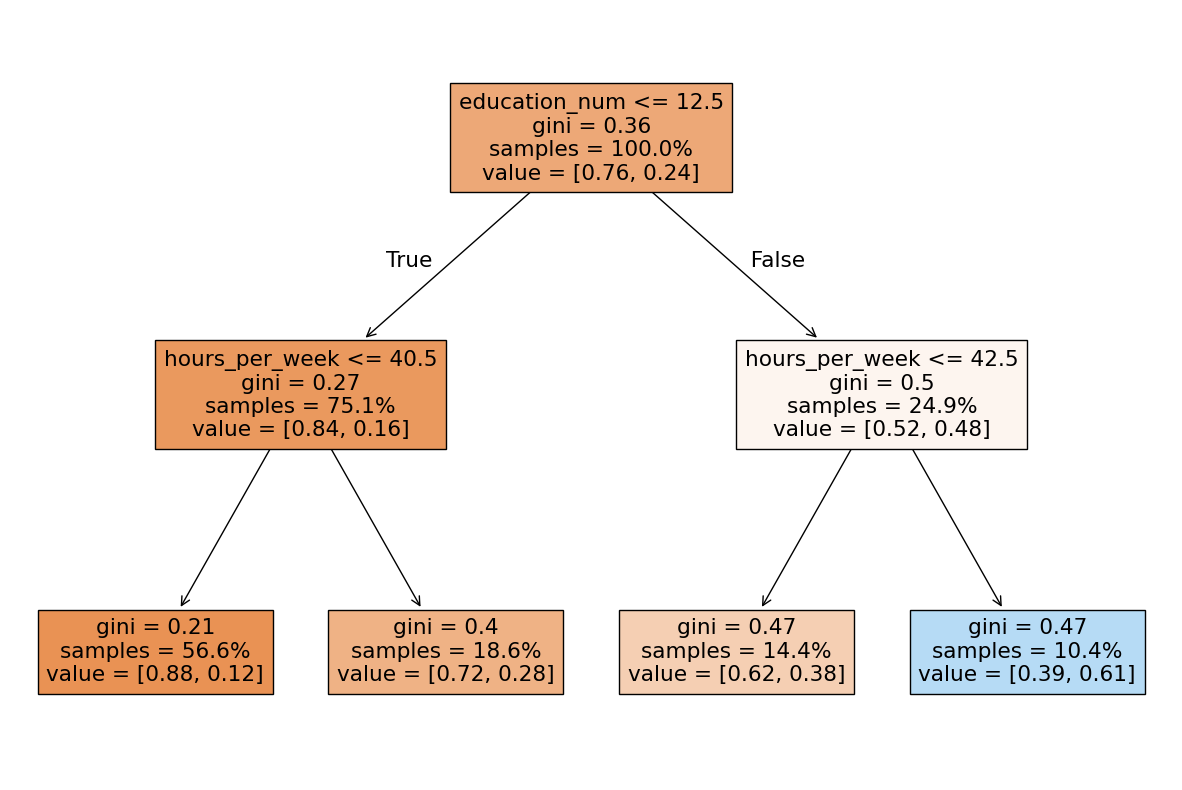

In [10]:
plot_tree(model, features=["education_num", "hours_per_week"])


The tree above is our model. Some terminology:
1. Root node - the starting node
2. Child node - one of the nodes created by the split
3. Terminal node or leaf - a node that is not split any further

We can use it to make predictions by going down the tree, treating each node as an if statement, until we reach the terminal node also called the leaf. Then our predicted probabilities are indicated by the `value` in that terminal node. 

In this case, only the node on the very right would give a prediction of income being a positive class above 50%. Namely, it would be 61%, which is simply the proportion of positive class cases in that leaf.

Another way to visualize our model is by looking at how it splits the feature space.


<Axes: xlabel='education_num', ylabel='hours_per_week'>

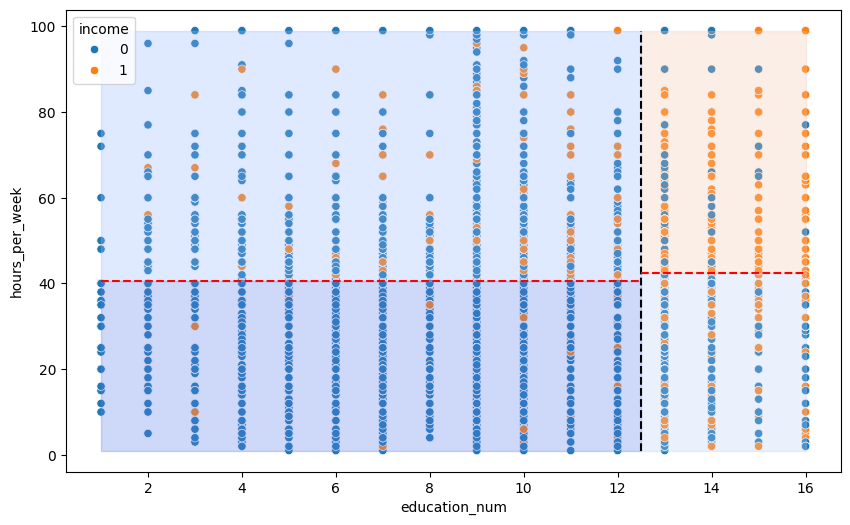

In [11]:
plot_tree_scatter(model, df_train, "income", "education_num", "hours_per_week")


Let's try to see what making predictions would look like for the tree above.

Imagine we want to predict the `income` variable for an adult that has 5 years of education and works 30 hours a week using the tree below. The tree first splits on `education_num`, so we go to the left side of the tree. Then it splits on `hours_per_week`, so we go to the left again. Now we've reached the terminal node and our prediction is 0.12 (or 0 if we apply the default threshold of 0.5).


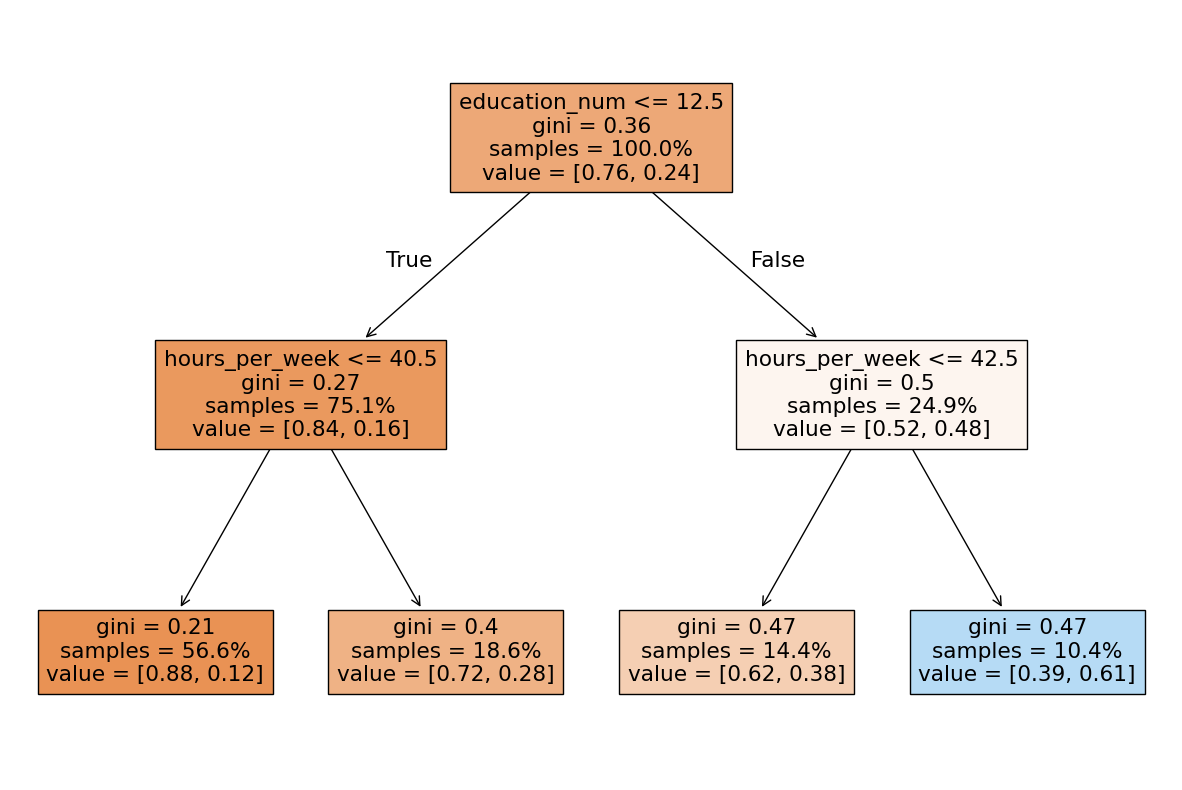

In [12]:
plot_tree(model, features=["education_num", "hours_per_week"])

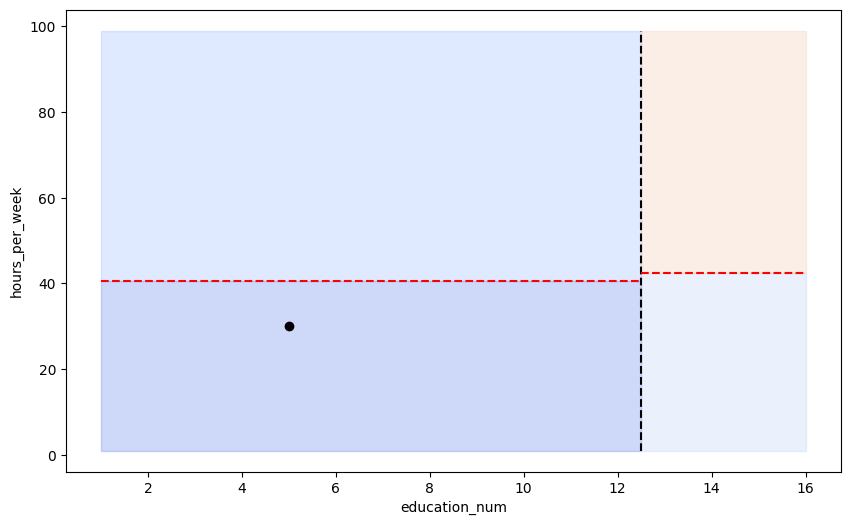

In [13]:
ax = plot_tree_scatter(
    model, df_train, "income", "education_num", "hours_per_week", scatterplot=False
)

ax.plot(5, 30, "ko")


Keep in mind that this model can only be visualized this way because we have two predictors.


We can also use categorical variables for decision trees. Let's fit a decision tree using just the `relationship` variable.


In [14]:
df['relationship'].unique()


array([' Not-in-family', ' Husband', ' Wife', ' Own-child', ' Unmarried',
       ' Other-relative'], dtype=object)

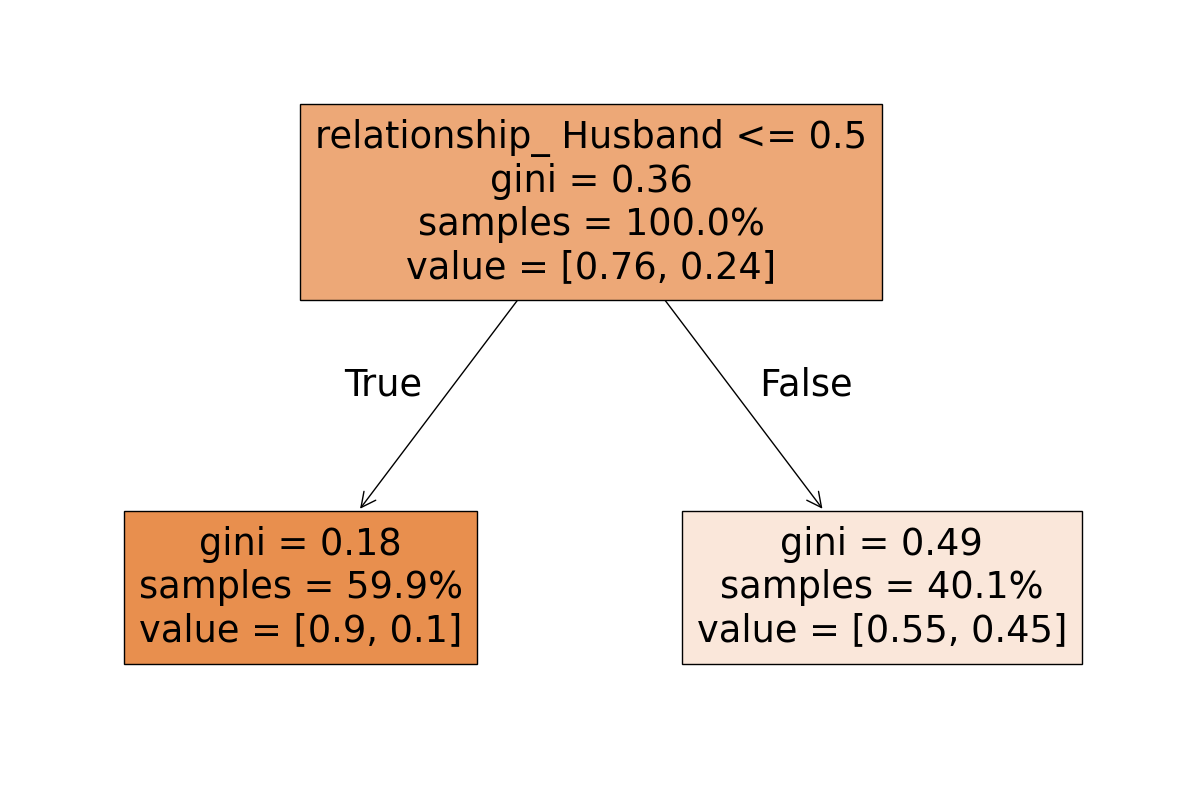

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X_train_rel = df_train[["relationship"]]
y_train = df_train["income"]

pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ("tree", DecisionTreeClassifier(max_depth=1)),
])

pipeline.fit(X_train_rel, y_train)

encoded_feature_names = pipeline.named_steps["encoder"].get_feature_names_out(["relationship"])
plot_tree(pipeline.named_steps["tree"], features=encoded_feature_names)


Likewise, how did the first model decide that it should split on `education_num`, and exactly at 12.5 years? Why did the model we fit above split the dataset according to whether `relationship` == 'Husband'? Why not any of the other values in the `relationship` column?

What we want is to somehow capture the impurity remaining after performing a certain split, calculate that for all possible splits and choose the split with the lowest remaining impurity. The metric that we use to calculate that remaining impurity is called weighted Gini index or weighted Gini impurity.

In a binary setting, Gini impurity for a single node is:

$$
\text{Gini}(p) = 1 - p^2 - (1-p)^2 = 2p(1-p)
$$

where $p$ is the share of class 1 in that node.

Weighted Gini impurity is then:

$$
\text{Gini}_{\text{weighted}} = \frac{n_{\text{left}}}{n}\text{Gini}_{\text{left}} + \frac{n_{\text{right}}}{n}\text{Gini}_{\text{right}}
$$


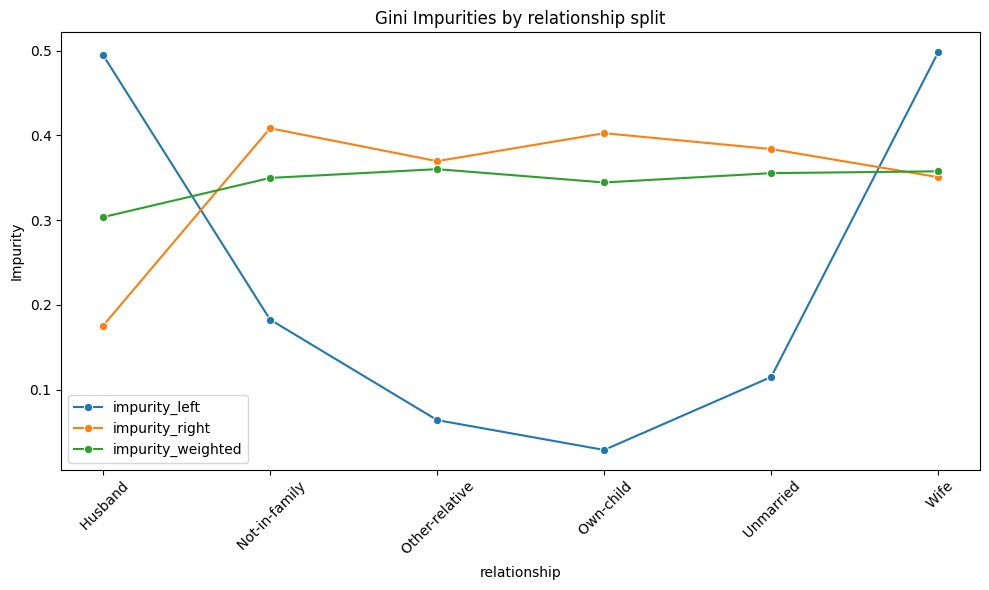

In [16]:
def gini_binary(y):
    p = y.mean()
    return 1 - p**2 - (1 - p)**2

relationship_impurities = []

for value in sorted(df_train["relationship"].unique()):
    y_group = df_train.loc[df_train["relationship"] == value, "income"]
    y_other = df_train.loc[df_train["relationship"] != value, "income"]

    impurity_left = gini_binary(y_group)
    impurity_right = gini_binary(y_other)
    impurity_weighted = (
        len(y_group) / len(df_train) * impurity_left
        + len(y_other) / len(df_train) * impurity_right
    )

    relationship_impurities.append({
        "relationship": value,
        "impurity_left": impurity_left,
        "impurity_right": impurity_right,
        "impurity_weighted": impurity_weighted,
    })

relationship_impurities = pd.DataFrame(relationship_impurities)

plt.figure(figsize=(10, 6))
sns.lineplot(data=relationship_impurities, x="relationship", y="impurity_left", marker="o", label="impurity_left")
sns.lineplot(data=relationship_impurities, x="relationship", y="impurity_right", marker="o", label="impurity_right")
sns.lineplot(data=relationship_impurities, x="relationship", y="impurity_weighted", marker="o", label="impurity_weighted")
plt.xticks(rotation=45)
plt.ylabel("Impurity")
plt.title("Gini Impurities by relationship split")
plt.tight_layout()


The plot above shows how splitting on `relationship = "Husband"` gives the lowest combined impurity, and that is the split that the decision tree above chose.

We can also try to visualize why the tree we fitted above decided to split at 12.5 for `education_num`.

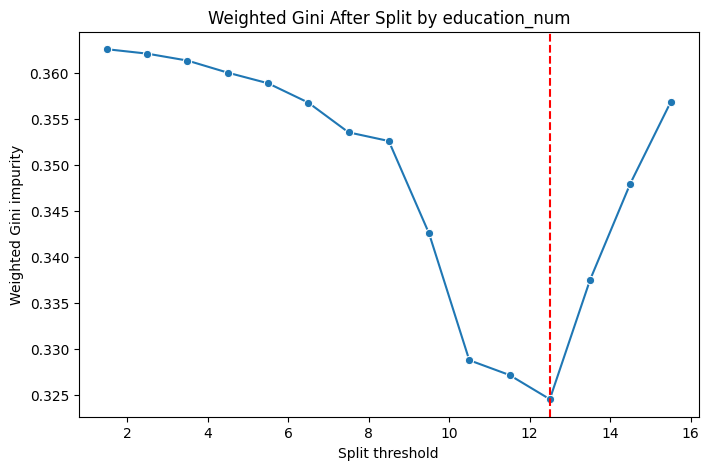

In [17]:
feature = "education_num"
target = "income"

def gini(y):
    p = y.value_counts(normalize=True)
    return 1 - np.sum(p**2)

X_train_edu_num = df_train[[feature]]
y_train = df_train[target]

unique_vals = np.sort(X_train_edu_num[feature].unique())
splits = (unique_vals[:-1] + unique_vals[1:]) / 2

results = []

for split in splits:
    y_left = y_train[X_train_edu_num[feature] <= split]
    y_right = y_train[X_train_edu_num[feature] > split]

    n = len(y_train)
    n_left = len(y_left)
    n_right = len(y_right)

    weighted_gini = (
        (n_left / n) * gini(y_left) +
        (n_right / n) * gini(y_right)
    )

    results.append({
        "split": split,
        "weighted_gini": weighted_gini,
        "n_left": n_left,
        "n_right": n_right,
    })

results = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
sns.lineplot(data=results, x="split", y="weighted_gini", marker="o")
best_split = results.loc[results["weighted_gini"].idxmin(), "split"]
plt.axvline(best_split, color="red", linestyle="--", label=f"best split = {best_split}")
plt.title("Weighted Gini After Split by education_num")
plt.xlabel("Split threshold")
plt.ylabel("Weighted Gini impurity");


We can see that the minimum is at 12.5, which is exactly the split that the tree we fitted above also chose, except that tree also considered all possible splits for `hours_per_week`.

To recap, a classification tree is fit using the following procedure:
1. Split the dataset into two parts using one of the features
2. Calculate weighted Gini impurity of that split
3. Repeat 1 and 2 for all possible splits of all features you're using
4. Choose the split that has lowest impurity
5. Repeat 1-5 until some stopping criterion is reached (such as `max_depth`)

For continuous features, "splitting the dataset" amounts to using all possible thresholds for the split. For categorical features, a split divides the categories into two groups. In our simple scikit-learn pipeline, this becomes one category versus the rest.


### Task

Find the optimal max_depth value. Use GridSearchCV.


{'max_depth': 6}


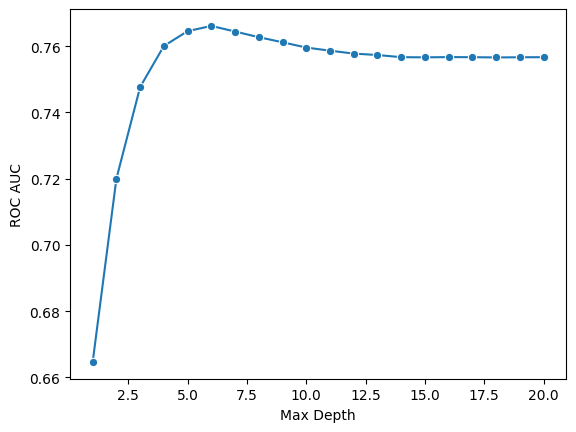

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth": range(1, 21)}
grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring="roc_auc")
grid_search.fit(X_train_edu_hours, y_train)

plot_df = pd.DataFrame(
    {"Max Depth": range(1, 21), "ROC AUC": grid_search.cv_results_["mean_test_score"]}
)

# Plot using seaborn
sns.lineplot(data=plot_df, x="Max Depth", y="ROC AUC", marker="o")

print(grid_search.best_params_)


What we see in action is overfitting - if we allow the tree to grow too deep, it will overfit to the data. In other words, individual decision trees have *very high variance* - there's a very high chance that they will overfit to the data.

Moreover, every decision tree is split greedily, by choosing the most optimal next split, not the most optimal sequence of splits. For this reason a standalone decision tree is rarely used.


## Bagging

Bagging (aka bootstrap aggregation) is an algorithm that fits multiple decision trees. To make each tree different, we use a bootstrapped dataset instead of the original dataset. A bootstrapped dataset is a synthetic dataset created by sampling *with replacement* the same amount of rows as the dataset contains.

In other words, the algorithm goes as follows - for `n_estimators` times:
1. Create a bootstrapped dataset by sampling from the original dataset with replacement.
2. Fit a regular decision tree on that dataset.

We end up with `n_estimators` decision trees, that are all slightly different, because they are fit on a bootstrapped dataset. This reduces variance - nstead of relying on one high-variance decision tree, we average over many trees.

To make predictions using such a model (the model is literally composed of `n_estimators` decision trees), you make predictions on each individual tree just like we did above and aggregate those predictions using e.g. majority vote or averaging probabilities that individual trees output.


In [19]:
from sklearn.model_selection import cross_val_score

dec_model = DecisionTreeClassifier(max_depth=10)
dec_model.fit(X_train_edu_hours, y_train)

np.mean(cross_val_score(dec_model, X_train_edu_hours, y_train, cv=5, scoring="roc_auc"))


np.float64(0.7596176802344724)

In [20]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=dec_model, n_estimators=20
)

bag_model.fit(X_train_edu_hours, y_train)
np.mean(cross_val_score(bag_model, X_train_edu_hours, y_train, cv=5, scoring="roc_auc"))


np.float64(0.7628860697333364)

With the bagging approach, we got a slightly better score than with an individual decision tree.

We can now look at individual trees from the bagging classifier and plot them on a scatterplot (the trees are too deep for a tree plot). Notice how each tree is different.



<Axes: xlabel='education_num', ylabel='hours_per_week'>

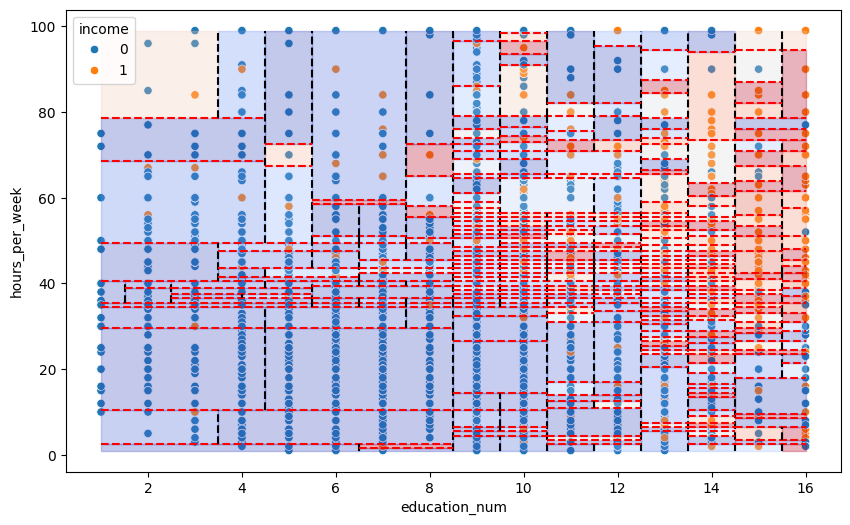

In [21]:
plot_tree_scatter(
    bag_model.estimators_[3], df_train, "income", "education_num", "hours_per_week"
)


What should we choose for `n_estimators`? It's a hyperparameter that we could tune with `GridSearchCV`. However, the only risk of setting `n_estimators` too high is that the model will take longer to fit.

Text(0.5, 1.0, 'Bagging Performance vs Number of Estimators')

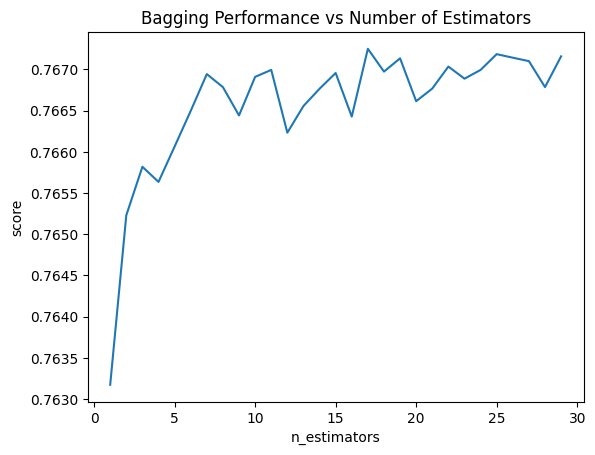

In [22]:
import seaborn as sns
import pandas as pd

N = range(1, 30)
all_scores = []

for i in N:
    bagging_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=6), n_estimators=i
    )
    scores = cross_val_score(bagging_model, X_train_edu_hours, y_train, cv=5, scoring="roc_auc")
    all_scores.append({"n_estimators": i, "score": scores.mean()})

plot_df = pd.DataFrame(all_scores)
sns.lineplot(data=plot_df, x="n_estimators", y="score")
plt.title("Bagging Performance vs Number of Estimators")


In this case we see that choosing `n_estimators` anywhere between 10 and 30 would be an OK choice.

## Random Forests

The bagging approach has one problem - the separate decision trees are highly correlated with each other. If our dataset contains one very informative feature, then most decision trees will use that feature for the first split, despite the fact that we're fitting the trees on bootstrapped datasets. A reduction in variance could be made larger if we found a way to decorrelate the decision trees.

The random forests algorithm addresses this.

## Training

Repeat `n_estimators` times:
1. Build a bootstrap dataset
2. Fit a decision tree until a stopping criteria is met, but on each split only choose from `max_features` random features.

Essentially, we're performing bagging, but with the additional step of choosing splits from random candidate features, rather than all features.

Stopping criteria can be:
1. `max_depth` - what is the maximum depth that a tree can reach?
2. `min_samples_split` - how many samples does a node have to have to be considered for splitting?
3. `min_impurity_decrease` - what is the minimum reduction in impurity (e.g. Gini coefficient) for a split to happen?

After training we have multiple decision trees, all of which are likely different from each other. We have our random forest.

**Predicting**. Just like in bagging - for each of the trees, make a prediction. Return the majority vote or average probability from each of the individual decision trees.



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=10, max_depth=6)

np.mean(cross_val_score(rf_model, X_train_edu_hours, y_train, cv=5, scoring="roc_auc"))


np.float64(0.766021438446625)

### Task

Fit a RandomForest classifier with n_estimators=10, using the listed features as predictors. Evaluate the model via cross validation.

In RandomForestClassifier you can set `n_jobs=-1` to speed up training.

Keep in mind that unlike last week, we do not need to apply scaling and polynomial transformations. The only preprocessing you need is one-hot encoding for categorical features.


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

categorical_features = ["workclass", "education", "occupation", "race"]
numeric_features = ["age", "education_num", "hours_per_week", "capital_gain"]


In [25]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", max_categories=10, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="passthrough"  # Keep numeric features as is
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=20, n_jobs=-1))
])

X_train_rf = df_train[categorical_features + numeric_features]
y_train = df_train["income"]

rf_score = np.mean(cross_val_score(pipeline, X_train_rf, y_train, cv=5, scoring="roc_auc"))
print(f"Random Forest ROC AUC: {rf_score:.4f}")


Random Forest ROC AUC: 0.8094


### Task

Choose three hyperparameters to tune from [documentation about RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

Fit a model with the optimal hyperparameters.


In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "rf__max_depth": range(1, 10),
    "rf__class_weight": ["balanced", None],
    "rf__min_samples_split": range(500, 1000, 100)
}


In [29]:

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc")
grid_search.fit(X_train_rf, y_train)

print(grid_search.best_params_)


{'rf__class_weight': 'balanced', 'rf__max_depth': 9, 'rf__min_samples_split': 600}


In [30]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=20, n_jobs=-1, max_depth=12, class_weight=None))
])
pipeline.fit(X_train_rf, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### Task

Report the results on the test set.
1. Report the metrics for a threshold of 0.5 and interpret them.
2. Show via a plot how the metrics change as you change the threshold.


In [29]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

X_test_rf = df_test[categorical_features + numeric_features]
y_test = df_test["income"]

y_score = pipeline.predict_proba(X_test_rf)[:, 1]
y_pred = (y_score >= 0.5).astype(int)

print(f"F1 Score: {f1_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")


F1 Score: 0.5255916345624656
Precision: 0.7652243589743589
Recall: 0.4002514668901928


<Axes: xlabel='threshold', ylabel='f1_score'>

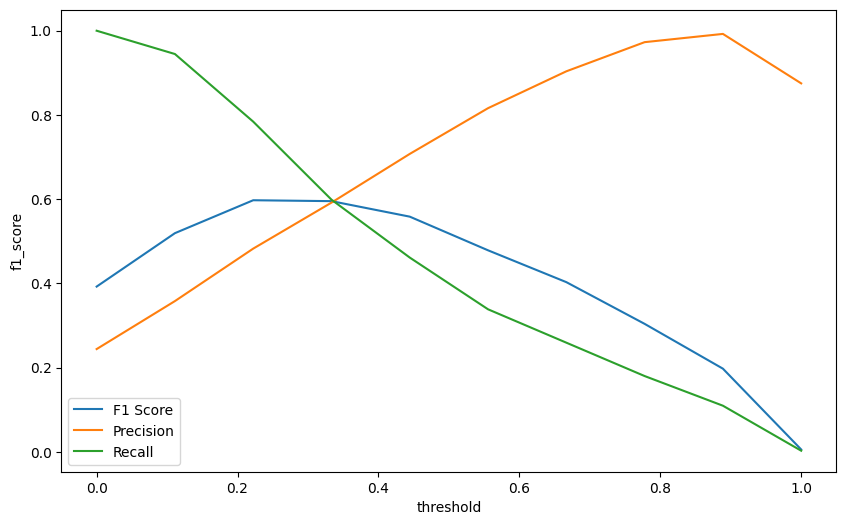

In [30]:

thresholds = np.linspace(0, 1, 10)
scores = []
for threshold in thresholds:
    y_pred = (y_score >= threshold).astype(int)
    scores.append(
        {
            "threshold": threshold,
            "f1_score": f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred)
        }
    )
threshold_df = pd.DataFrame(scores)

plt.figure(figsize=(10, 6))
sns.lineplot(data=threshold_df, x='threshold', y='f1_score', label='F1 Score')
sns.lineplot(data=threshold_df, x='threshold', y='precision', label='Precision')
sns.lineplot(data=threshold_df, x='threshold', y='recall', label='Recall')


## Recap
- A decision tree is a very simple algorithm, but it's considered a weak learner - it has high variance.
- Bagging and random forest are both ensemble methods. Bagging is rarely used as a standalone method, but is an important component of the random forest algorithm.
- key hyperparameters of decision trees and random forests:
    - `max_depth` - how deep the trees are allowed to grow
    - `min_samples_split` - the minimum number of samples that have to be in a node for a split to occur
    - `min_impurity_decrease` - the minimum decrease in impurity that we require for a split to occur
    - `n_estimators` - how many trees are we fitting
- Decision trees are easy to inspect and interpret - the tree structure makes it easy to understand what the model is doing 
- We lose that interpretability with random forests, because now we have many decision trees instead of just one
